<a href="https://colab.research.google.com/github/rlakshmi2k24/Learning_journey_1/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   patient_id  age gender       city insurance_provider  chronic_flag registration_date
0           1   53      M  Hyderabad         SecureLife             0        14-05-2025
1           2   42      M       Pune         HealthPlus             0        18-11-2025
2           3   56      F  Hyderabad         HealthPlus             0        11-05-2025
3           4   72      M    Chennai         HealthPlus             0        18-12-2025
4           5   40      F  Bangalore            CareOne             1        23-01-2025
   visit_id  patient_id  visit_date   department visit_type  length_of_stay_hours risk_score  doctor_id
0         1         756  18-10-2025   Cardiology         ER                  3.48        Low        169
1         2        4102  06-04-2025  Orthopedics        OPD                 15.31       High        148
2         3        2964  13-07-2025          ICU         ER                 34.36        Low        153
3         4        4496  19-11-2025   Cardiology        

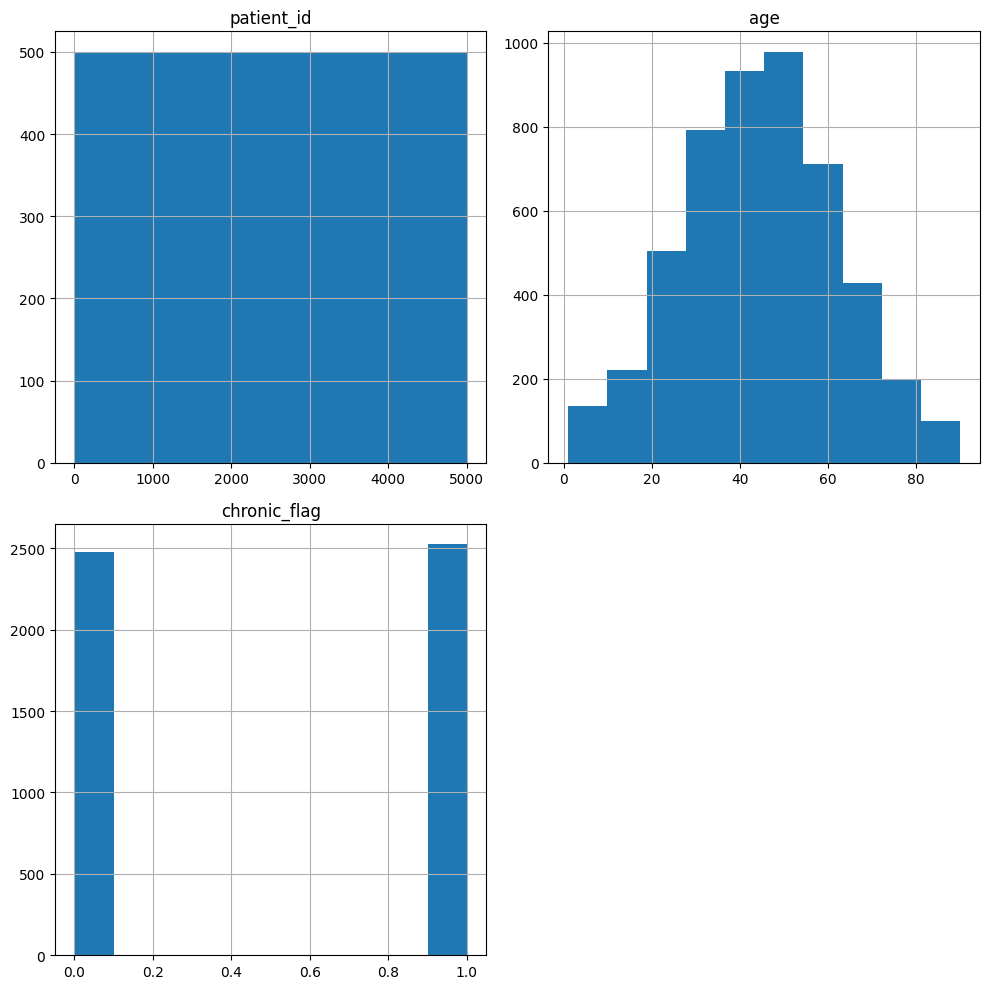

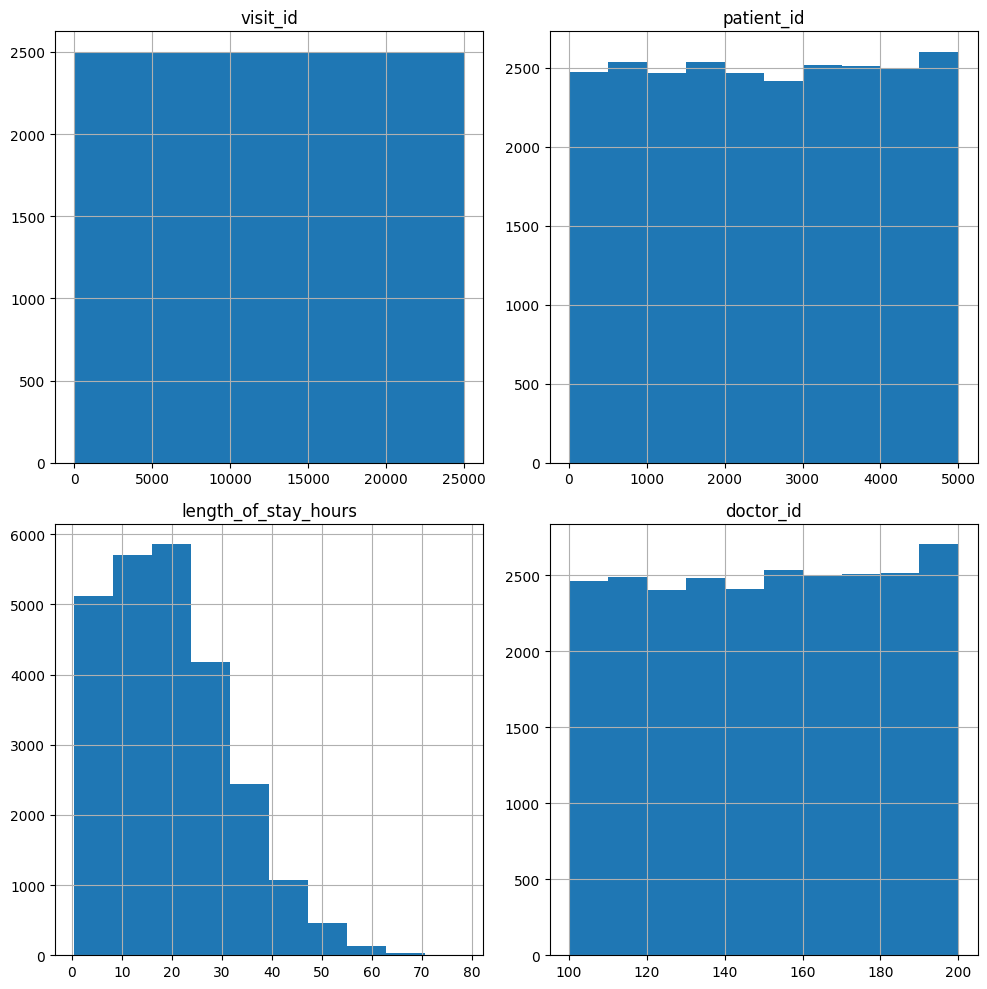

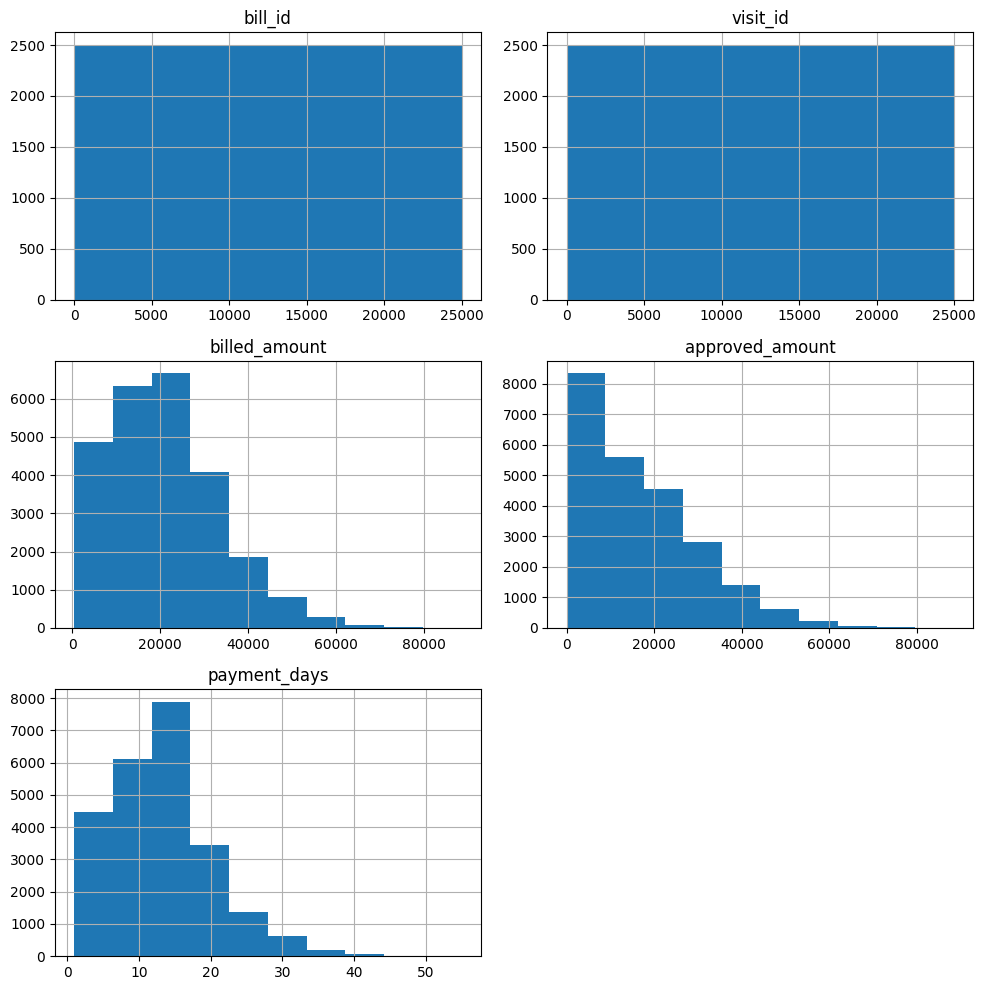

Patients shape: (5000, 7)
Visits shape: (25000, 8)
Billing shape: (25000, 7)
Patients Data Types
patient_id             int64
age                    int64
gender                object
city                  object
insurance_provider    object
chronic_flag           int64
registration_date     object
dtype: object

Visits Data Types
visit_id                  int64
patient_id                int64
visit_date               object
department               object
visit_type               object
length_of_stay_hours    float64
risk_score               object
doctor_id                 int64
dtype: object

Billing Data Types
bill_id              int64
visit_id             int64
billed_amount      float64
approved_amount    float64
claim_status        object
payment_days       float64
billing_date        object
dtype: object

Missing Value Report: patients
               column  missing_count  missing_percentage
0          patient_id              0                 0.0
1                 age       

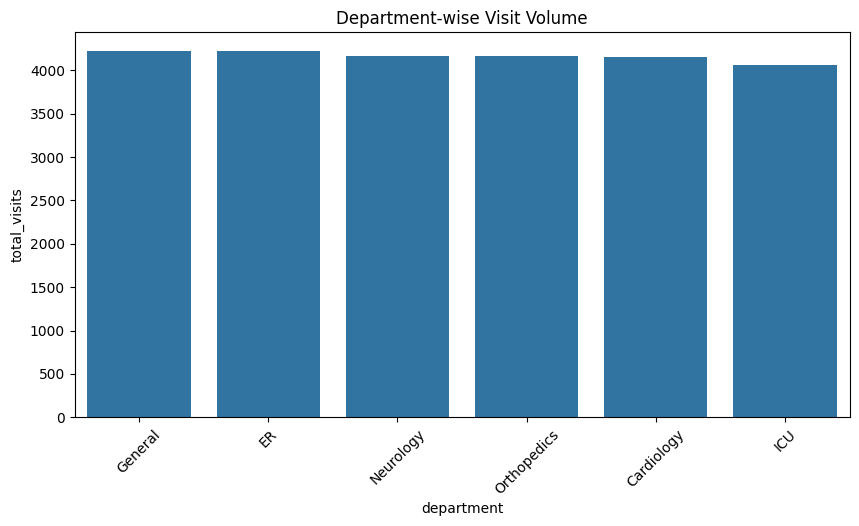

    department  avg_length_of_stay_hours
4    Neurology                 19.718098
5  Orthopedics                 19.662656
0   Cardiology                 19.600962
1           ER                 19.534967
2      General                 19.434905
3          ICU                 19.355234


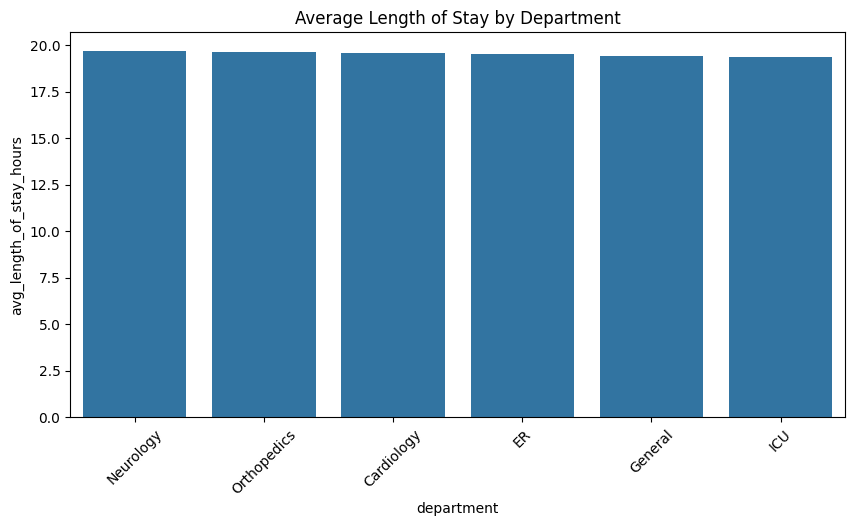

    department  total_visits  high_risk_visits  high_risk_percentage
3          ICU          4064               845                 20.79
1           ER          4220               872                 20.66
4    Neurology          4165               846                 20.31
5  Orthopedics          4164               842                 20.22
2      General          4228               839                 19.84
0   Cardiology          4159               790                 18.99
  insurance_provider  total_billed  total_approved  revenue_gap  avg_payment_days  realization_ratio
2          MediCareX  1.345912e+08    1.001355e+08  27979514.55              13.0             0.7440
0            CareOne  1.307080e+08    9.699776e+07  26703903.77              13.0             0.7421
1         HealthPlus  1.301807e+08    9.625178e+07  26621682.18              13.1             0.7394
3         SecureLife  1.262890e+08    9.377089e+07  26308152.46              13.1             0.7425
  insurance_

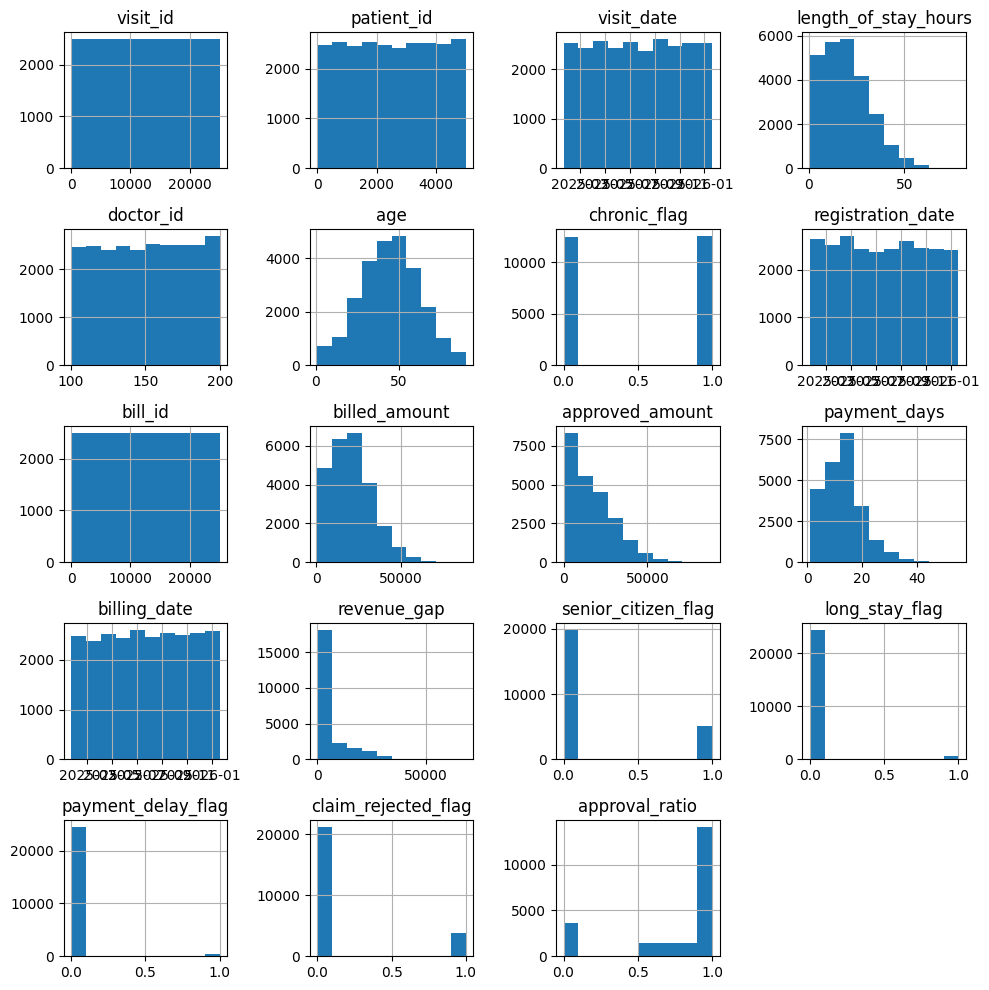

(           visit_id   patient_id                     visit_date  length_of_stay_hours     doctor_id           age  chronic_flag           registration_date       bill_id  billed_amount  approved_amount  payment_days                   billing_date   revenue_gap  senior_citizen_flag  long_stay_flag  payment_delay_flag  claim_rejected_flag  approval_ratio
 count  25000.000000  25000.00000                          25000          25000.000000  25000.000000  25000.000000  25000.000000                       25000  25000.000000   25000.000000     23682.000000  24210.000000                          25000  23682.000000         25000.000000    25000.000000        25000.000000         25000.000000    23682.000000
 mean   12500.500000   2509.51536  2025-07-21 15:25:51.743999744             19.551584    150.172400     44.768320      0.502600  2025-07-18 16:17:11.040000  12500.500000   20870.757442     16348.107777     13.048079  2025-07-22 19:06:38.592000256   4544.094796             0.205960      

In [2]:
# ============================================================
# 1. Import required libraries
# ============================================================

# pandas is used for reading CSV files, cleaning data, joining tables,
# and performing exploratory data analysis.
import pandas as pd

# numpy is used for numerical operations and handling missing/infinite values.
import numpy as np

# matplotlib and seaborn are used for charts and visual analysis.
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns clearly in notebook output.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# ============================================================
# 2. Load source CSV files
# ============================================================

# These files represent the hospital data foundation:
# patients  -> demographic and insurance details
# visits    -> operational and clinical encounter details
# billing   -> claim, billed amount, approval and payment details

patients = pd.read_csv("/content/sample_data/patients.csv")
visits = pd.read_csv("/content/sample_data/visits.csv")
billing = pd.read_csv("/content/sample_data/billing.csv")

# Display first few rows to verify successful loading.
print(patients.head())
print(visits.head())
print(billing.head())

#Descriptive Stats to understand the "patients" data
patients_stats = patients.describe()

#missing values "Only 0 is Considered"
patients_missing_values = patients.isnull().sum()

#plot histogram
patients.hist(figsize=(10,10))
plt.tight_layout()
plt.show()
patients_stats,patients_missing_values

#Descriptive Stats to understand the "visits" data
visits_stats = visits.describe()

#missing values "Only 0 is Considered"
visits_missing_values = visits.isnull().sum()

#plot histogram
visits.hist(figsize=(10,10))
plt.tight_layout()
plt.show()
visits_stats,visits_missing_values


#Descriptive Stats to understand the "billing" data
billing_stats = billing.describe()

#missing values "Only 0 is Considered"
billing_missing_values = billing.isnull().sum()

#plot histogram
billing.hist(figsize=(10,10))
plt.tight_layout()
plt.show()
billing_stats,billing_missing_values

# ============================================================
# 3. Understand dataset size
# ============================================================

# Shape helps us understand row and column count.
# This is important before analysis to confirm whether data volume
# matches expectations.

print("Patients shape:", patients.shape)
print("Visits shape:", visits.shape)
print(
"Billing shape:", billing.shape)

# ============================================================
# 4. Check data types
# ============================================================

# Data type validation is important because wrong data types can break analysis.
# Example: date columns loaded as text cannot be used for time-based analysis.

print("Patients Data Types")
print(patients.dtypes)

print("\nVisits Data Types")
print(visits.dtypes)

print("\nBilling Data Types")
print(billing.dtypes)

# ============================================================
# 5. Convert date columns
# ============================================================

# CSV files usually load dates as object/text.
# We convert them into datetime format for monthly trend analysis,
# registration trend, visit trend, and billing delay analysis.

patients["registration_date"] = pd.to_datetime(
    patients["registration_date"],
    format="%d-%m-%Y"
)

visits["visit_date"] = pd.to_datetime(
    visits["visit_date"],
    format="%d-%m-%Y"
)
billing["billing_date"] = pd.to_datetime(
    billing["billing_date"],
    format="%d-%m-%Y"
)

# ============================================================
# 6. Missing value analysis
# ============================================================

# Missing values can affect dashboards and machine learning models.
# For example:
# - Missing insurance provider affects claim analysis
# - Missing payment_days affects payment delay analysis
# - Missing approved_amount affects revenue realization

def missing_value_report(df, table_name):
    report = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isnull().sum().values,
        "missing_percentage": (df.isnull().mean() * 100).round(2).values
    })

    print(f"\nMissing Value Report: {table_name}")
    print(report.sort_values("missing_percentage", ascending=False))

missing_value_report(patients, "patients")
missing_value_report(visits, "visits")
missing_value_report(billing, "billing")

# ============================================================
# 7. Duplicate record check
# ============================================================

# Duplicate primary keys are serious data quality issues.
# patient_id, visit_id, and bill_id should be unique.

print("Duplicate patient_id:", patients["patient_id"].duplicated().sum())
print("Duplicate visit_id:", visits["visit_id"].duplicated().sum())
print("Duplicate bill_id:", billing["bill_id"].duplicated().sum())

# ============================================================
# 8. Primary key and foreign key validation
# ============================================================

# This checks whether:
# - Every visit has a valid patient
# - Every billing record has a valid visit
# These checks are important before joining data.

visits_without_patient = visits[
    ~visits["patient_id"].isin(patients["patient_id"])
]

billing_without_visit = billing[
    ~billing["visit_id"].isin(visits["visit_id"])
]

print("Visits without valid patient:", len(visits_without_patient))
print("Billing records without valid visit:", len(billing_without_visit))

# ============================================================
# 9. Merge datasets for business analysis
# ============================================================

# We combine patients, visits, and billing into one analytical dataset.
# This dataset will be used for operational, financial, and ML analysis.

df = (
    visits
    .merge(patients, on="patient_id", how="left")
    .merge(billing, on="visit_id", how="left")
)

print("Merged analytical dataset shape:", df.shape)
print(df.head())

# ============================================================
# 10. Basic statistical summary
# ============================================================

# Summary statistics help understand range, average, spread, and abnormal values.
# Important columns:
# - age
# - length_of_stay_hours
# - billed_amount
# - approved_amount
# - payment_days

numeric_columns = [
    "age",
    "length_of_stay_hours",
    "billed_amount",
    "approved_amount",
    "payment_days"
]

df[numeric_columns].describe()

# ============================================================
# 11. Categorical distribution analysis
# ============================================================

# This helps leadership understand hospital demand patterns.
# Example:
# - Which department receives most visits?
# - Which visit type is common?
# - Which claim status dominates?

categorical_columns = [
    "gender",
    "city",
    "insurance_provider",
    "department",
    "visit_type",
    "risk_score",
    "claim_status"
]

for col in categorical_columns:
    print(f"\nDistribution of {col}")
    print(df[col].value_counts(dropna=False))

# ============================================================
# 12. Operational analysis: department visit volume
# ============================================================

# This identifies departments with the highest patient load.

department_volume = (
    df.groupby("department")["visit_id"]
    .count()
    .reset_index(name="total_visits")
    .sort_values("total_visits", ascending=False)
)

print(department_volume)

plt.figure(figsize=(10, 5))
sns.barplot(data=department_volume, x="department", y="total_visits")
plt.xticks(rotation=45)
plt.title("Department-wise Visit Volume")
plt.show()

# ============================================================
# 13. Patient flow analysis: average length of stay
# ============================================================

# Longer length of stay may indicate operational bottlenecks,
# slow discharge process, or higher patient complexity.

avg_los = (
    df.groupby("department")["length_of_stay_hours"]
    .mean()
    .reset_index(name="avg_length_of_stay_hours")
    .sort_values("avg_length_of_stay_hours", ascending=False)
)

print(avg_los)

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_los, x="department", y="avg_length_of_stay_hours")
plt.xticks(rotation=45)
plt.title("Average Length of Stay by Department")
plt.show()

# ============================================================
# 14. High-risk visit analysis
# ============================================================

# High-risk visits are important for clinical operations,
# ICU planning, doctor workload, and resource allocation.

high_risk_summary = (
    df.assign(high_risk_flag=np.where(df["risk_score"] == "High", 1, 0))
    .groupby("department")
    .agg(
        total_visits=("visit_id", "count"),
        high_risk_visits=("high_risk_flag", "sum")
    )
    .reset_index()
)

high_risk_summary["high_risk_percentage"] = (
    high_risk_summary["high_risk_visits"]
    / high_risk_summary["total_visits"]
    * 100
).round(2)

high_risk_summary = high_risk_summary.sort_values(
    "high_risk_percentage",
    ascending=False
)

print(high_risk_summary)

# ============================================================
# 15. Financial analysis: billed vs approved amount
# ============================================================

# This identifies revenue realization and leakage.
# Revenue leakage = billed amount - approved amount.

df["revenue_gap"] = df["billed_amount"] - df["approved_amount"]

financial_summary = (
    df.groupby("insurance_provider")
    .agg(
        total_billed=("billed_amount", "sum"),
        total_approved=("approved_amount", "sum"),
        revenue_gap=("revenue_gap", "sum"),
        avg_payment_days=("payment_days", "mean")
    )
    .reset_index()
    .round({"total_billed": 4, "total_approved": 4, "revenue_gap": 4, "avg_payment_days": 1})
)

financial_summary["realization_ratio"] = (
    financial_summary["total_approved"]
    / financial_summary["total_billed"]
).round(4)

print(financial_summary.sort_values("revenue_gap", ascending=False))

# ============================================================
# 16. Claim rejection analysis
# ============================================================

# Rejected claims directly impact hospital cash flow.
# This analysis identifies insurance providers with higher rejection risk.

claim_summary = (
    df.assign(rejected_flag=np.where(df["claim_status"] == "Rejected", 1, 0))
    .groupby("insurance_provider")
    .agg(
        total_claims=("bill_id", "count"),
        rejected_claims=("rejected_flag", "sum")
    )
    .reset_index()
)

claim_summary["rejection_rate_percentage"] = (
    claim_summary["rejected_claims"]
    / claim_summary["total_claims"]
    * 100
).round(2)

print(claim_summary.sort_values("rejection_rate_percentage", ascending=False))

# ============================================================
# 17. Outlier detection using IQR
# ============================================================

# Outliers are extreme values that may be valid business cases
# or data quality problems.
# Example:
# - Very high billed amount
# - Very long length of stay
# - Very high payment delay

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(f"\nOutlier Report for {column}")
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Outlier count:", len(outliers))

    return outliers

los_outliers = detect_outliers_iqr(df, "length_of_stay_hours")
billing_outliers = detect_outliers_iqr(df, "billed_amount")
payment_outliers = detect_outliers_iqr(df, "payment_days")

# ============================================================
# 18. Invalid value checks
# ============================================================

# Negative values in operational and financial fields are invalid.
# These checks help establish data trust.

invalid_los = df[df["length_of_stay_hours"] < 0]
invalid_billed = df[df["billed_amount"] < 0]
invalid_approved = df[df["approved_amount"] < 0]
invalid_payment_days = df[df["payment_days"] < 0]

print("Invalid length_of_stay_hours:", len(invalid_los))
print("Invalid billed_amount:", len(invalid_billed))
print("Invalid approved_amount:", len(invalid_approved))
print("Invalid payment_days:", len(invalid_payment_days))

# ============================================================
# 19. Feature engineering for ML readiness
# ============================================================

# These derived variables convert raw business data into ML-friendly features.

df["senior_citizen_flag"] = np.where(df["age"] >= 60, 1, 0)

df["long_stay_flag"] = np.where(df["length_of_stay_hours"] > 48, 1, 0)

df["payment_delay_flag"] = np.where(df["payment_days"] > 30, 1, 0)

df["claim_rejected_flag"] = np.where(df["claim_status"] == "Rejected", 1, 0)

df["approval_ratio"] = (
    df["approved_amount"] / df["billed_amount"]
).replace([np.inf, -np.inf], np.nan)

print(df[[
    "patient_id",
    "visit_id",
    "department",
    "risk_score",
    "senior_citizen_flag",
    "long_stay_flag",
    "payment_delay_flag",
    "claim_rejected_flag",
    "revenue_gap",
    "approval_ratio"
]].head())

# ============================================================
# 20. Save cleaned analytical dataset
# ============================================================

# This output can be used in later phases:
# - predictive modeling
# - MLflow tracking
# - dashboard development

df.to_csv("healthcare_analytical_dataset.csv", index=False)

print("Cleaned analytical dataset saved successfully.")


#Descriptive Stats to understand the data
stats = df.describe()

#missing values "Only 0 is Considered"
missing_values = df.isnull().sum()

#plot histogram
df.hist(figsize=(10,10))
plt.tight_layout()
plt.show()
stats,missing_values
